# Classification model for sustained commission decline

This notebook builds and evaluates the classification component of the project. The target identifies whether an advertiser's commission declines over the following 12 months relative to the preceding 12 months.

The analysis has four purposes:

1. compare the existing 12-month year-on-year rule with fitted classification models
2. test whether a full feature set adds value beyond a simpler model
3. translate model performance into gross-profit-weighted business measures
4. examine how the model score behaves across risk bands and client-level outcomes



## 1. Environment


In [38]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier


In [39]:
get_ipython().run_line_magic('matplotlib', 'inline') #added to fix the problem of the plots not showing up properly in the jupyter notebook.


## 2. Configuration

The paths and modelling constants are defined in one place. The primary population requires an available three-month year-on-year momentum measure. Programmes without this measure are separated by age: genuinely new programmes are excluded from algorithmic scoring, while established programmes form a small fallback population.

Features are grouped to reflect the project framing:

- **Momentum:** recent growth, persistence of decline, volatility and quarter-to-quarter changes.
- **Publisher engagement:** publisher mix, funnel diversity and shifts in the publisher portfolio.
- **Firmographic and commercial:** programme scale, fee mix, age, platform/service indicators.

The full model uses all three groups. The reduced model uses only three-month momentum, providing a direct test of whether the wider feature set adds useful information.

-  I used 15 months as the cutoff for a programme to be treated as established. This is a judgement call rather than a fitted threshold. Younger programmes are excluded because they do not have enough history for the three-month YoY measure.
- I kept all three acceleration features. Earlier EDA suggested that accel_q2_to_q1 contained useful information even though its raw correlation with decline was close to zero, so I did not want to remove the other acceleration measures based on correlation alone. I check their value again later in the notebook.
- platform_rank, service_rank and is_exclusive are current-state fields and cannot be reconstructed historically. I keep them in the main model but rerun the model without them later as a sensitivity check.
- I used relatively conservative Random Forest and XGBoost settings rather than carrying out a large hyperparameter search. The dataset is fairly noisy and my priority was performance on unseen data rather than maximising the training result.


In [40]:
DATA_PATH = Path(r"C:\Users\ian.forbes\FinalProject\processed\modelling_dataset_jan25.csv")
OOT_PATH  = Path(r"C:\Users\ian.forbes\FinalProject\processed\observation_panel.csv")
OUT_DIR   = Path(r"C:\Users\ian.forbes\FinalProject\outputs\classification_full")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.30
TARGET       = "target_decline"
N_SPLITS     = 5
OOT_CUTOFF   = pd.Timestamp("2025-04-01")

YOUNG_THRESHOLD_MONTHS = 15

RAW_REQUIRED_COLS = [
    "commission_l12m", "core_gp_l12m", "tracking_gp_l12m",
    "momentum_3m_yoy", "commission_yoy_growth", "commission_cv_l12m",
    "fixed_fee_share_mean_l12m", "programme_age_months", "etr_mean_l12m",
    "negative_growth_months_l12m", "consecutive_declining_months",
    "zero_commission_months", "active_months_l12m", "programme_count",
    "partially_closed_last_12m", "former_sas_flag", "is_exclusive",
    "has_cpi_flag", "platform_rank", "service_rank",
    "momentum_q1_yoy", "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy",
    "commission_forward_12m", TARGET,
]

PUBLISHER_FEATURES = [
    "pub_share_lower_2024", "pub_share_mid_2024", "pub_share_upper_2024",
    "pub_share_technical_2024", "pub_funnel_diversity",
    "pub_lower_funnel_shift_yoy", "pub_mid_funnel_shift_yoy",
    "pub_upper_funnel_shift_yoy", "has_pub_data",
]

FIRMOGRAPHIC_FEATURES = [
    "log_commission_l12m", "log_core_gp_l12m", "etr_mean_l12m",
    "fixed_fee_share_mean_l12m", "zero_commission_months",
    "active_months_l12m", "programme_age_months", "programme_count",
    "partially_closed_last_12m", "former_sas_flag", "is_exclusive",
    "has_cpi_flag", "platform_rank", "service_rank", "commission_size_tier_code",
]

MOMENTUM_FEATURES = [
    "momentum_3m_yoy", "momentum_3m_yoy_missing",
    "negative_growth_months_l12m", "consecutive_declining_months",
    "commission_cv_l12m",
    "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy",
    "momentum_q2_yoy_missing", "momentum_q3_yoy_missing", "momentum_q4_yoy_missing",
    "accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
    "worsening_negative_trend", "recent_reversal_to_decline",
]

FULL_FEATURES = FIRMOGRAPHIC_FEATURES + MOMENTUM_FEATURES + PUBLISHER_FEATURES

REDUCED_FEATURES_3M_ONLY = ["momentum_3m_yoy", "momentum_3m_yoy_missing"]

FALLBACK_FEATURES = [
    "negative_growth_months_l12m", "consecutive_declining_months", "commission_cv_l12m",
]

UNDATEABLE_FIELDS = ["platform_rank", "service_rank", "is_exclusive"]

rf_params = dict(n_estimators=500, min_samples_leaf=20, max_features="sqrt",
                 n_jobs=-1, random_state=RANDOM_STATE)
xgb_params = dict(n_estimators=500, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)


## 3. Load and validate the modelling dataset

The processed January 2025 modelling dataset is loaded from the output of the preceding data-preparation notebook. Required columns are checked before modelling so that the notebook stops early if the dataset schema is incomplete.

In [41]:

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw: {df.shape[0]:,} rows, {df.shape[1]} columns")



Raw: 15,247 rows, 82 columns


## 4. Feature engineering

Rows with no commission in the preceding 12 months are removed because the target and year-on-year growth measures are not relevant when there is no previous commission base.

The main transformations are:

- commission and Core GP are log-transformed to reduce the influence of highly skewed values (EDA showed that there is indeed a very large skew)
- commission is grouped into size tiers for modelling and later diagnostics
- missing indicators are created for momentum fields where absence may in itself be meaningful
- two trajectory flags distinguish a continuing negative trend from a recent reversal into decline
- adjacent-quarter acceleration features measure whether momentum is improving or worsening

Missing publisher values are treated as zero where the source data indicates no recorded publisher activity. There are some gaps in the publisher data that cannot be resolved from the available sources, so this remains a data limitation.


- Commission size tiers are used as a model feature, but I also use them later to check whether model performance is consistent across different client sizes.
- The two trajectory flags capture genuinely different risk stories: `worsening_negative_trend` flags a client that is negative both recently and over the full year, while `recent_reversal_to_decline` flags a client whose full-year number still looks fine but has just turned negative - a case the current 12-month rule would completely miss.


In [42]:
pre = len(df)
df = df[df["commission_l12m"] > 0].copy()
print(f"Removed {pre - len(df):,} advertisers with no commission. {len(df):,} are left.")

tier_bins   = [-np.inf, 1_000, 10_000, 100_000, 1_000_000, np.inf]
tier_labels = ["micro", "small", "mid", "large", "strategic"]
df["commission_size_tier"]      = pd.cut(df["commission_l12m"], bins=tier_bins, labels=tier_labels)
df["commission_size_tier_code"] = df["commission_size_tier"].cat.codes

df["log_commission_l12m"] = np.log1p(df["commission_l12m"].clip(lower=0))
df["log_core_gp_l12m"]    = np.log1p(df["core_gp_l12m"].clip(lower=0))

df["momentum_3m_yoy_missing"] = df["momentum_3m_yoy"].isna().astype(int)
df["momentum_3m_yoy"]         = df["momentum_3m_yoy"].fillna(0)
df["commission_cv_l12m"]        = df["commission_cv_l12m"].fillna(0)
df["fixed_fee_share_mean_l12m"] = df["fixed_fee_share_mean_l12m"].fillna(0)
df["programme_age_months"]      = df["programme_age_months"].fillna(df["programme_age_months"].median())
df["etr_mean_l12m"]             = df["etr_mean_l12m"].fillna(df["etr_mean_l12m"].median())

for col in ["momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[f"{col}_missing"] = df[col].isna().astype("int8")

for col in PUBLISHER_FEATURES:
    df[col] = df[col].fillna(0)

df = df[df[TARGET].notna()].copy()
df[TARGET] = df[TARGET].astype(int)

q1      = df["momentum_q1_yoy"]
yoy_12m = df["commission_yoy_growth"]

df["worsening_negative_trend"] = (
    q1.notna() & yoy_12m.notna() & (q1 < 0) & (yoy_12m < 0) & (q1 < yoy_12m)
).astype("int8")
df["recent_reversal_to_decline"] = (
    q1.notna() & yoy_12m.notna() & (q1 < 0) & (yoy_12m >= 0)
).astype("int8")

df["accel_q2_to_q1"] = df["momentum_q1_yoy"] - df["momentum_q2_yoy"]
df["accel_q3_to_q2"] = df["momentum_q2_yoy"] - df["momentum_q3_yoy"]
df["accel_q4_to_q3"] = df["momentum_q3_yoy"] - df["momentum_q4_yoy"]

for c in ["accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
          "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[c] = df[c].fillna(0)


print(f"\nTotal advertisers: {len(df):,} , with a decline rate of {df[TARGET].mean():.1%}")


Removed 1,286 advertisers with no commission. 13,961 are left.

Total advertisers: 13,961 , with a decline rate of 44.3%


## 5. Modelling scope

The population is divided into three operational segments:

- **in scope:** three-month momentum is available and the primary model is applied;
- **excluded - too young:** the programme lacks sufficient history for a reliable year-on-year comparison and by nature they will be growing anyway due to ramp up of a program
- **fallback - established but sparse:** the programme is old enough to be established but three-month momentum cannot be calculated.

The scope table reports both client share and Core GP share so that the commercial importance of each segment is visible.

In [43]:
df["scope_segment"] = np.select(
    [
        df["momentum_3m_yoy_missing"] == 0,
        (df["momentum_3m_yoy_missing"] == 1) & (df["programme_age_months"] < YOUNG_THRESHOLD_MONTHS),
        (df["momentum_3m_yoy_missing"] == 1) & (df["programme_age_months"] >= YOUNG_THRESHOLD_MONTHS),
    ],
    ["in_scope", "excluded_too_young", "fallback_established_sparse"],
    default="unclassified",
)

print('====SCOPE====')
scope_summary = df.groupby("scope_segment").agg(
    count=("commission_l12m", "count"),
    gp_total=("core_gp_l12m", lambda x: x.clip(lower=0).sum()),
    decline_rate=(TARGET, "mean"),
    median_age=("programme_age_months", "median"),
)
scope_summary["gp_share"] = scope_summary["gp_total"] / scope_summary["gp_total"].sum()
scope_summary["client_share"] = scope_summary["count"] / scope_summary["count"].sum()
print(scope_summary.round(3).to_string())

df_in_scope = df[df["scope_segment"] == "in_scope"].copy()
df_fallback = df[df["scope_segment"] == "fallback_established_sparse"].copy()
df_excluded = df[df["scope_segment"] == "excluded_too_young"].copy()


====SCOPE====
                             count      gp_total  decline_rate  median_age  gp_share  client_share
scope_segment                                                                                     
excluded_too_young            2909  6.325150e+06         0.205         7.0     0.048         0.208
fallback_established_sparse    474  3.712945e+05         0.445        32.0     0.003         0.034
in_scope                     10578  1.263205e+08         0.509        43.0     0.950         0.758


## 6. Reusable modelling functions

`evaluate` reports both standard and GP-weighted precision, recall, F1 and AUC. I keep both because the number of clients and the value of GP affected can give different views of performance.

`evaluate_negative_class` repeats the evaluation from the non-decliner perspective as a secondary diagnostic.

Thresholds are selected using out-of-fold probabilities from the training data rather than the test set, so the test set is not used to choose the threshold. The remaining functions create the threshold and lift charts and keep the fitting process consistent across the three algorithms.

In [44]:
def build_weights(values):
    v = np.clip(np.asarray(values, dtype=float), 0, None)
    return v / v.mean()

def evaluate(y_true, y_pred, y_proba, weights, label, threshold, model_name):
    """Return client-level and GP-weighted decline metrics."""
    return {
        "model":        model_name,
        "algo":         label,
        "threshold":    threshold,
        "gp_precision": precision_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        "gp_recall":    recall_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        "gp_f1":        f1_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        "accuracy":     accuracy_score(y_true, y_pred),
        "precision":    precision_score(y_true, y_pred, zero_division=0),
        "recall":       recall_score(y_true, y_pred, zero_division=0),
        "f1":           f1_score(y_true, y_pred, zero_division=0),
        "auc_roc":      roc_auc_score(y_true, y_proba)                        if y_proba is not None else np.nan,
        "gp_auc_roc":   roc_auc_score(y_true, y_proba, sample_weight=weights) if y_proba is not None else np.nan,
    }

def evaluate_negative_class(y_true, y_pred, weights):
    """Return GP-weighted metrics with non-decline treated as the positive class."""
    y_true_neg = 1 - y_true                                                   
    y_pred_neg = 1 - y_pred                                              
    return {
        "gp_negative_precision": precision_score(y_true_neg, y_pred_neg, sample_weight=weights, zero_division=0),
        "gp_negative_recall":    recall_score(y_true_neg, y_pred_neg, sample_weight=weights, zero_division=0),
        "gp_negative_f1":        f1_score(y_true_neg, y_pred_neg, sample_weight=weights, zero_division=0),
    }

def tune_threshold(y_true, y_proba, weights):
    thresholds = np.arange(0.20, 0.81, 0.01)
    scores = [
        f1_score(y_true, (y_proba >= t).astype(int), sample_weight=weights, zero_division=0)
        for t in thresholds
    ]
    best_idx = int(np.argmax(scores))
    return thresholds[best_idx], thresholds, scores

def tune_safe_threshold(y_true, y_proba, weights):
    """Select the threshold that maximises GP-weighted non-decliner F1."""
    thresholds = np.arange(0.20, 0.81, 0.01)
    scores = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        neg_metrics = evaluate_negative_class(y_true, pred, weights)
        scores.append(neg_metrics["gp_negative_f1"])
    best_idx = int(np.argmax(scores))
    return thresholds[best_idx], thresholds, scores

def plot_threshold_sweep(thresholds, scores, best_t, label, ylabel="GP-weighted F1 (OOF)"):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(thresholds, scores)
    ax.axvline(best_t, linestyle="--", color="grey")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Threshold sweep: {label}  (best = {best_t:.2f})")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"threshold_sweep_{label}.png", dpi=150)
    plt.show()
    plt.close(fig)

def plot_lift_curve(y_true, y_proba, gp_values, label):
    """Plot cumulative declining GP after ranking clients from highest risk."""
    df_lift = pd.DataFrame({"y": y_true, "p": y_proba, "gp": gp_values})
    df_lift = df_lift.sort_values("p", ascending=False).reset_index(drop=True)
    df_lift["at_risk_gp"] = df_lift["gp"] * df_lift["y"]
    total_at_risk = df_lift["at_risk_gp"].sum()
    df_lift["cum_share"] = df_lift["at_risk_gp"].cumsum() / total_at_risk
    df_lift["pop_share"] = (df_lift.index + 1) / len(df_lift)

    deciles  = np.arange(0.1, 1.01, 0.1)
    captured = [
        df_lift.loc[df_lift["pop_share"] <= d, "at_risk_gp"].sum() / total_at_risk
        for d in deciles
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df_lift["pop_share"], df_lift["cum_share"], label="Model")
    ax.plot([0, 1], [0, 1], "--", color="grey", label="Random baseline")
    ax.set_xlabel("Share of population (ranked by predicted decline risk, highest first)")
    ax.set_ylabel("Cumulative share of at-risk GP captured")
    ax.set_title(f"GP-at-risk lift curve: {label}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"lift_curve_{label}.png", dpi=150)
    plt.show()
    plt.close(fig)
    return pd.DataFrame({"decile": deciles, "at_risk_gp_captured": captured})

def plot_safe_lift_curve(y_true, y_proba, gp_values, label):
    """Plot cumulative non-declining GP after ranking clients from lowest risk."""
    df_lift = pd.DataFrame({"y": y_true, "p": y_proba, "gp": gp_values})
    df_lift = df_lift.sort_values("p", ascending=True).reset_index(drop=True)                     
    df_lift["safe_gp"] = df_lift["gp"] * (1 - df_lift["y"])                                  
    total_safe = df_lift["safe_gp"].sum()
    df_lift["cum_share"] = df_lift["safe_gp"].cumsum() / total_safe
    df_lift["pop_share"] = (df_lift.index + 1) / len(df_lift)

    deciles  = np.arange(0.1, 1.01, 0.1)
    captured = [
        df_lift.loc[df_lift["pop_share"] <= d, "safe_gp"].sum() / total_safe
        for d in deciles
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df_lift["pop_share"], df_lift["cum_share"], label="Model")
    ax.plot([0, 1], [0, 1], "--", color="grey", label="Random baseline")
    ax.set_xlabel("Share of population (ranked by predicted risk, LOWEST first)")
    ax.set_ylabel("Cumulative share of genuinely-safe GP captured")
    ax.set_title(f"Safe-client GP lift curve: {label}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"safe_lift_curve_{label}.png", dpi=150)
    plt.show()
    plt.close(fig)
    return pd.DataFrame({"decile": deciles, "safe_gp_captured": captured})

def make_estimator(label, use_imputer=False):
    if label.startswith("logistic"):
        steps = []
        if use_imputer:
            steps.append(("imputer", SimpleImputer(strategy="median", add_indicator=True)))
        steps += [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=0.1,
                                        max_iter=1000, random_state=RANDOM_STATE)),
        ]
        return Pipeline(steps)
    if label.startswith("rf"):
        return RandomForestClassifier(**rf_params)
    if label.startswith("xgb"):
        return XGBClassifier(**xgb_params)
    raise ValueError(label)

def compute_oof(label, X, y):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    for tr, va in skf.split(X, y):
        est = make_estimator(label, use_imputer=label.startswith("logistic"))
        est.fit(X.iloc[tr], y[tr])
        oof[va] = est.predict_proba(X.iloc[va])[:, 1]
    return oof

def cv_fold_scores(label, X, y, w_eval, threshold, n_splits=N_SPLITS):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr, va in skf.split(X, y):
        est = make_estimator(label, use_imputer=label.startswith("logistic"))
        est.fit(X.iloc[tr], y[tr])
        p = est.predict_proba(X.iloc[va])[:, 1]
        scores.append(f1_score(y[va], (p >= threshold).astype(int),
                               sample_weight=w_eval[va], zero_division=0))
    return float(np.mean(scores)), float(np.std(scores))


## 7. Train/test split

The dataset is split into a 70% training set and a 30% test set. Stratifying ensures the decline rate in both samples is maintained. Core GP weights are created separately for the training and test sets.

In [45]:
train_df, test_df = train_test_split(
    df_in_scope, test_size=TEST_SIZE, stratify=df_in_scope[TARGET], random_state=RANDOM_STATE
)
y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values
w_eval_train = build_weights(train_df["core_gp_l12m"].values)
w_eval_test  = build_weights(test_df["core_gp_l12m"].values)

print(f"\nIn-scope train: {len(train_df):,} rows ({train_df[TARGET].mean():.1%} decline)")
print(f"In-scope test:  {len(test_df):,} rows ({test_df[TARGET].mean():.1%} decline)")

## Create the empty containers for the results
results          = []
negative_results = []
model_store      = {}
lift_tables      = {}
safe_lift_tables = {}



In-scope train: 7,404 rows (50.9% decline)
In-scope test:  3,174 rows (50.9% decline)


**Note** the decline rate is 50.9% in both the training and test samples, so the stratified split has ensured the same the target as intended.

## 8. Existing business-rule baseline

The first benchmark applies the existing rule: an advertiser is classified as declining when its preceding 12-month commission growth is negative. This establishes the performance that a fitted model must improve upon.

In [46]:
b1_pred = (test_df["commission_yoy_growth"].fillna(0) < 0).astype(int).values
results.append(evaluate(y_test, b1_pred, None, w_eval_test, "business rule", "n/a", "baseline_12m_yoy"))
print(f"\nBaseline (12M-YoY rule) GP-F1: {results[0]['gp_f1']:.4f}")



Baseline (12M-YoY rule) GP-F1: 0.4158


## 9. Full-model comparison

I compare three classification approaches using the full feature set:

- L1-regularised logistic regression as a simpler linear benchmark;
- Random Forest; and
- XGBoost.

Random Forest and XGBoost allow non-linear relationships and interactions that the logistic model cannot capture directly.

For each model, out-of-fold training probabilities are used to select the GP-weighted F1 threshold. I also calculate a separate threshold for identifying safe clients. Final performance is then measured on the held-out test set.

- All three models use the same feature set and train/test split, so differences in performance are not caused by different input data.
- The decline threshold and safe-client threshold answer different questions, so I tune them separately.


=====STEP 2: FULL MODEL with all features, in-scope clients only=====


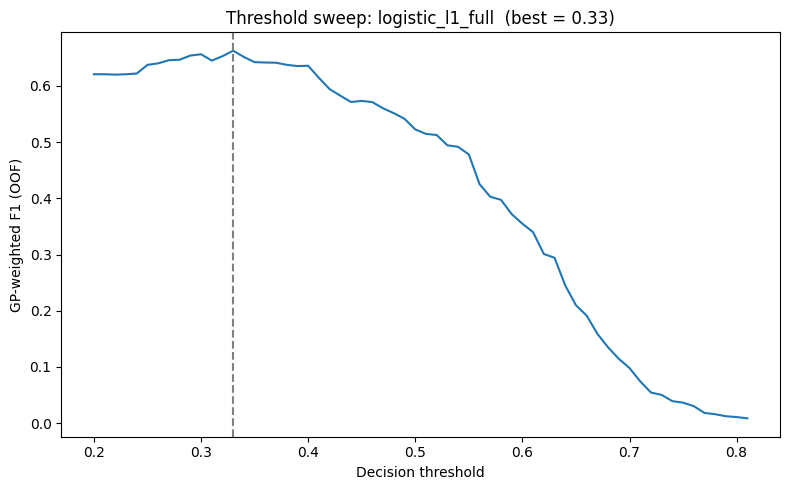

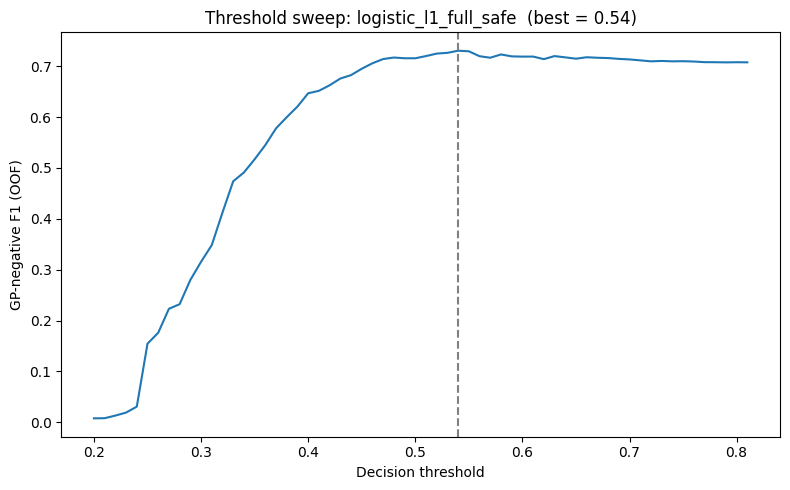

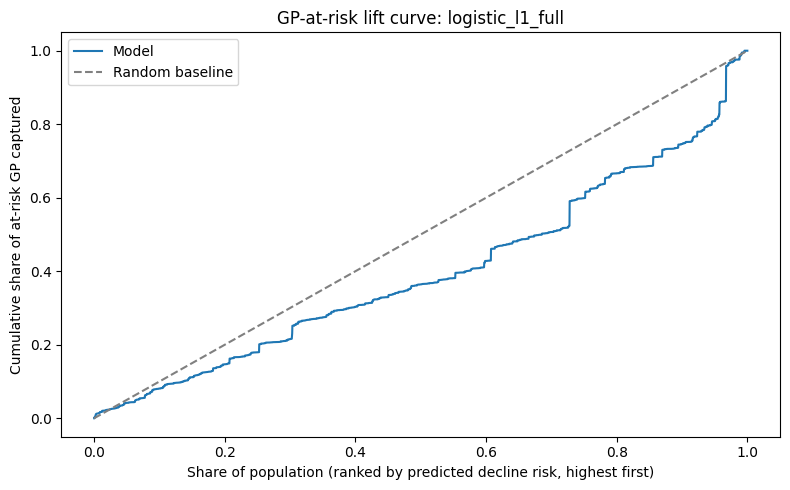

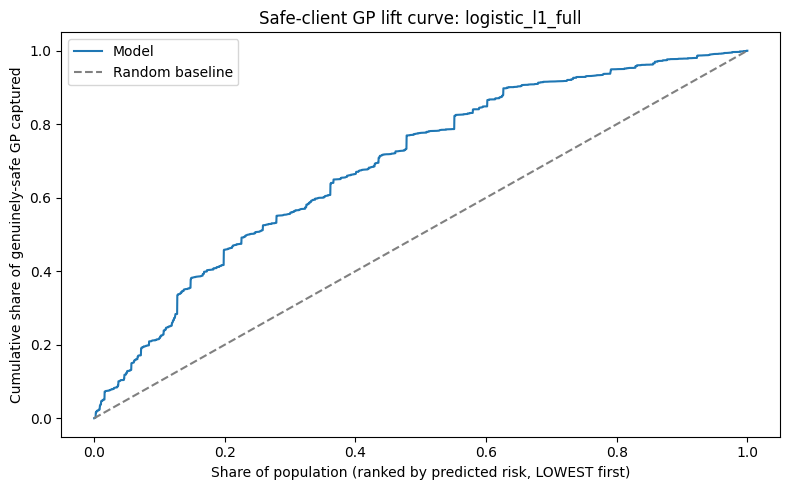

      logistic_l1_full: GP-F1=0.5629  thr=0.33  gp_auc=0.567  CV=0.6616±0.0254
                        [decline-thr]  gp_negative_recall=0.160  gp_negative_precision=0.484
                        [safe-thr=0.54]  gp_negative_recall=0.829  gp_negative_precision=0.595


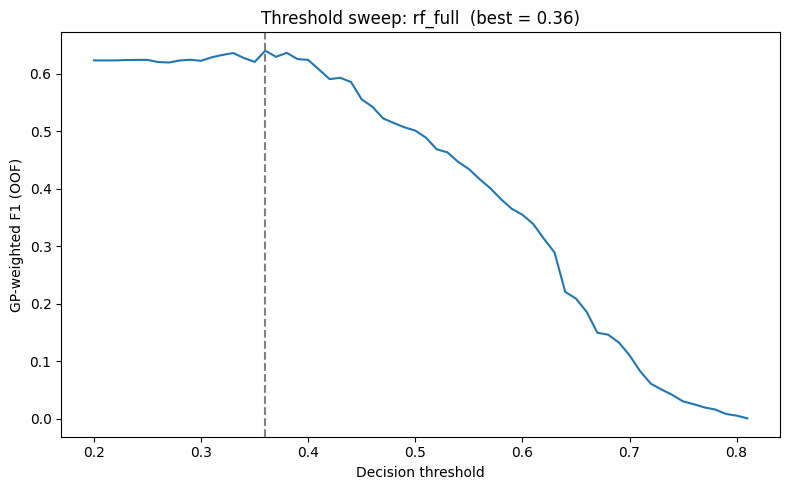

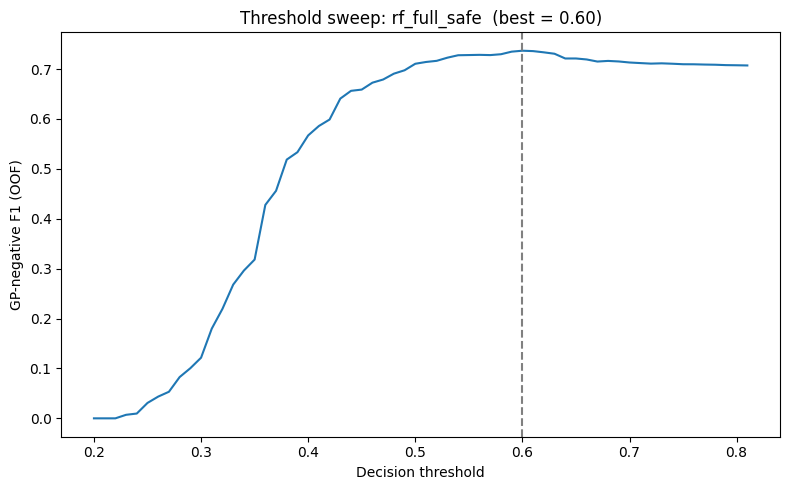

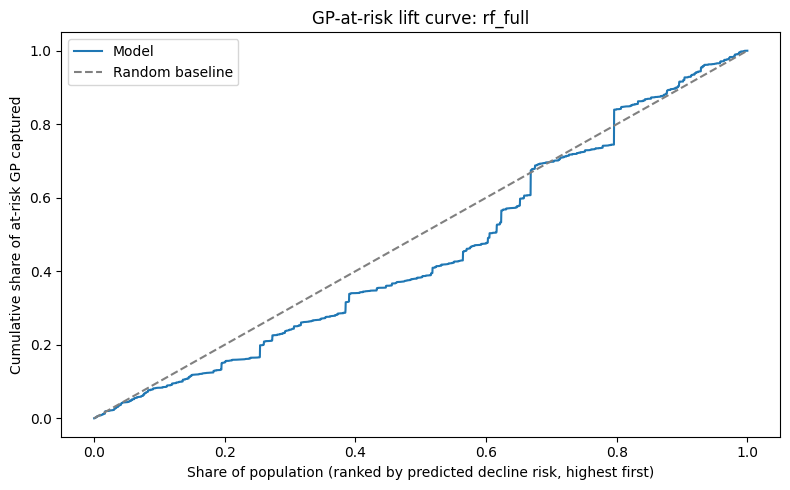

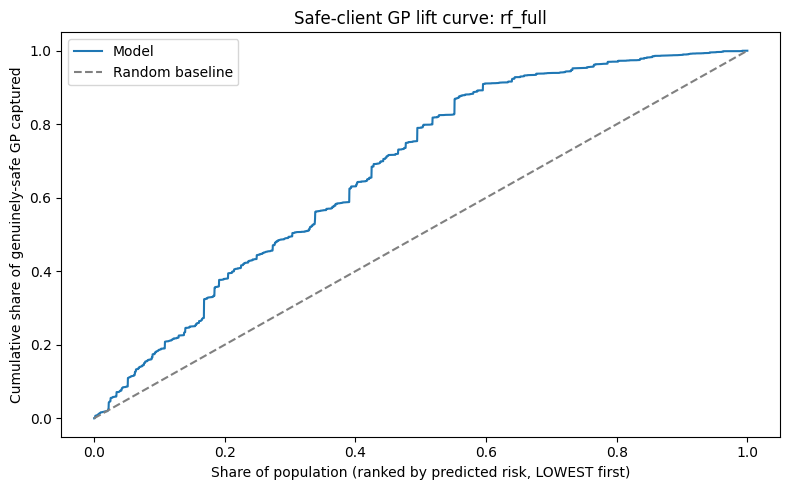

               rf_full: GP-F1=0.6264  thr=0.36  gp_auc=0.638  CV=0.6399±0.0152
                        [decline-thr]  gp_negative_recall=0.212  gp_negative_precision=0.708
                        [safe-thr=0.60]  gp_negative_recall=0.948  gp_negative_precision=0.594


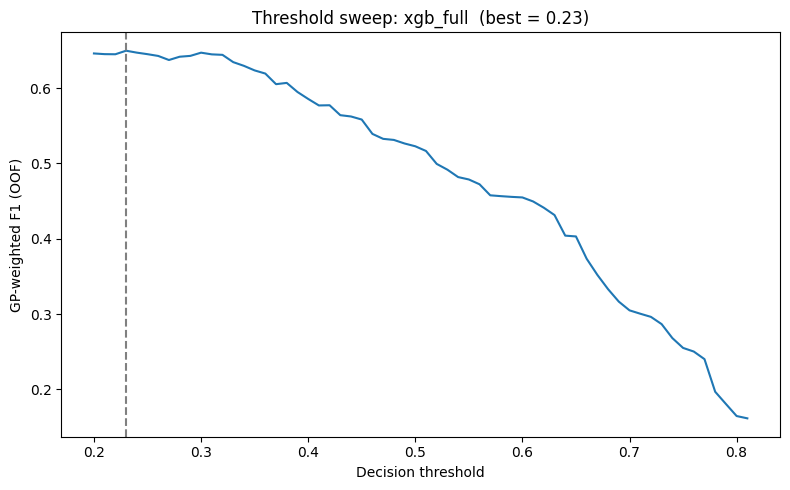

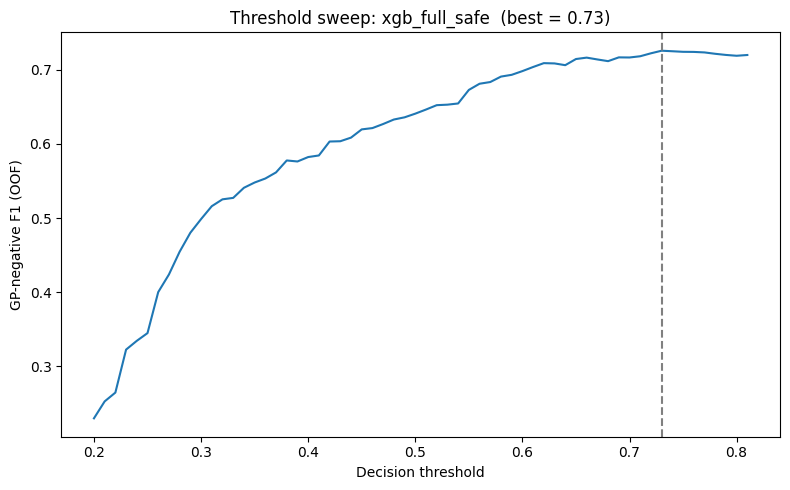

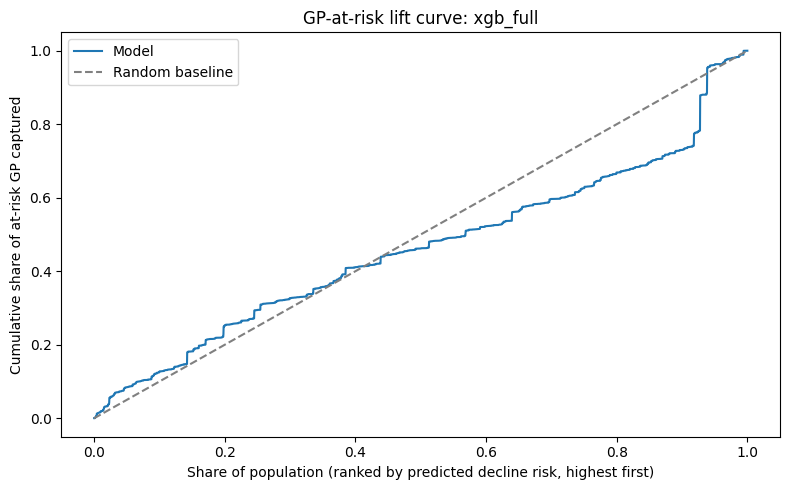

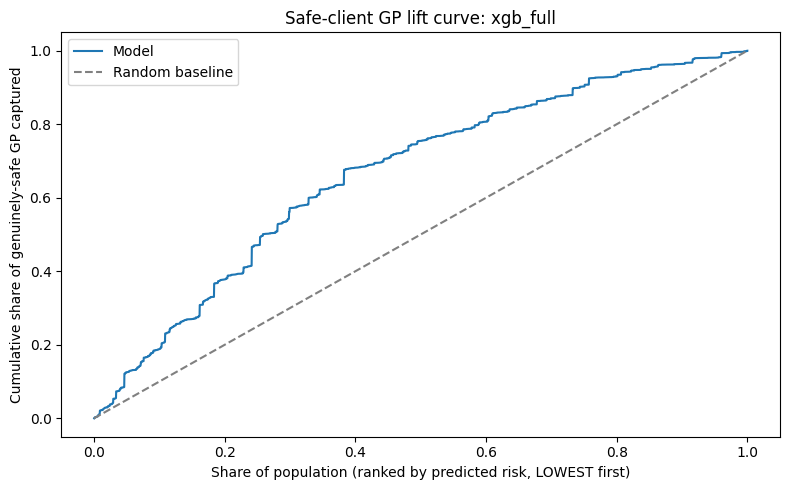

              xgb_full: GP-F1=0.6336  thr=0.23  gp_auc=0.596  CV=0.6492±0.0207
                        [decline-thr]  gp_negative_recall=0.132  gp_negative_precision=0.776
                        [safe-thr=0.73]  gp_negative_recall=0.962  gp_negative_precision=0.575

Negative-class (non-decliner) evaluation full comparison:
 gp_negative_precision  gp_negative_recall  gp_negative_f1            model    threshold_type  threshold
                0.4841              0.1603          0.2408 logistic_l1_full decline_optimised       0.33
                0.5955              0.8293          0.6932 logistic_l1_full    safe_optimised       0.54
                0.7080              0.2125          0.3268          rf_full decline_optimised       0.36
                0.5937              0.9476          0.7300          rf_full    safe_optimised       0.60
                0.7764              0.1316          0.2250         xgb_full decline_optimised       0.23
                0.5751              0.9624  

In [47]:
print('=====STEP 2: FULL MODEL with all features, in-scope clients only=====')

model_specs = [("logistic_l1", "logistic"), ("rf", "rf"), ("xgb", "xgb")]

full_thresholds      = {}
full_safe_thresholds = {}

for model_name, algo in model_specs:
    label = f"{model_name}_full"
    Xtr, Xte = train_df[FULL_FEATURES], test_df[FULL_FEATURES]

    est = make_estimator(algo, use_imputer=(algo == "logistic"))
    est.fit(Xtr, y_train)
    proba_te = est.predict_proba(Xte)[:, 1]
    oof = compute_oof(algo, Xtr, y_train)

    t, thr_grid, thr_scores = tune_threshold(y_train, oof, w_eval_train)
    plot_threshold_sweep(thr_grid, thr_scores, t, label)

    row = evaluate(y_test, (proba_te >= t).astype(int), proba_te, w_eval_test,
                   algo, round(float(t), 2), label)
    results.append(row)
    model_store[label] = (est, FULL_FEATURES)
    full_thresholds[model_name] = t

    neg_at_decline_t = evaluate_negative_class(y_test, (proba_te >= t).astype(int), w_eval_test)
    neg_at_decline_t.update({"model": label, "threshold_type": "decline_optimised", "threshold": round(float(t), 2)})
    negative_results.append(neg_at_decline_t)

    t_safe, safe_grid, safe_scores = tune_safe_threshold(y_train, oof, w_eval_train)
    plot_threshold_sweep(safe_grid, safe_scores, t_safe, f"{label}_safe", ylabel="GP-negative F1 (OOF)")
    full_safe_thresholds[model_name] = t_safe

    neg_at_safe_t = evaluate_negative_class(y_test, (proba_te >= t_safe).astype(int), w_eval_test)
    neg_at_safe_t.update({"model": label, "threshold_type": "safe_optimised", "threshold": round(float(t_safe), 2)})
    negative_results.append(neg_at_safe_t)

    cv_m, cv_s = cv_fold_scores(algo, Xtr, y_train, w_eval_train, t)
    lift_tables[label] = plot_lift_curve(y_test, proba_te, test_df["core_gp_l12m"].values, label)
    safe_lift_tables[label] = plot_safe_lift_curve(y_test, proba_te, test_df["core_gp_l12m"].values, label)

    print(f"  {label:>20}: GP-F1={row['gp_f1']:.4f}  thr={t:.2f}  "
          f"gp_auc={row['gp_auc_roc']:.3f}  CV={cv_m:.4f}±{cv_s:.4f}")
    print(f"  {'':>20}  [decline-thr]  gp_negative_recall={neg_at_decline_t['gp_negative_recall']:.3f}  "
          f"gp_negative_precision={neg_at_decline_t['gp_negative_precision']:.3f}")
    print(f"  {'':>20}  [safe-thr={t_safe:.2f}]  gp_negative_recall={neg_at_safe_t['gp_negative_recall']:.3f}  "
          f"gp_negative_precision={neg_at_safe_t['gp_negative_precision']:.3f}")

neg_df = pd.DataFrame(negative_results).round(4)
neg_df.to_csv(OUT_DIR / "negative_class_evaluation.csv", index=False)

print(f"\nNegative-class (non-decliner) evaluation full comparison:")
print(neg_df.to_string(index=False))



## 10. Model selection and SHAP interpretation

The preferred full model is selected using GP-weighted AUC. AUC is threshold-independent and is therefore more appropriate than a single-threshold F1 score when the continuous risk score is passed into the pricing model.

For a selected tree model, SHAP values estimate the contribution of each feature to individual predictions. The summary chart reports global feature importance using mean absolute SHAP values. Results are also aggregated into the three feature groups defined earlier. If logistic regression were selected instead, the notebook would report its non-zero coefficients.

I selected the preferred full model using GP-weighted AUC rather than the best F1 at a single threshold. XGBoost produces the highest GP-F1 (0.6336), but Random Forest has the stronger GP-AUC (0.6380 compared with 0.5963). As the later pricing model uses the continuous risk score rather than only the binary classification, I retain Random Forest as the preferred model.



Best full model by GP-AUC: rf_full


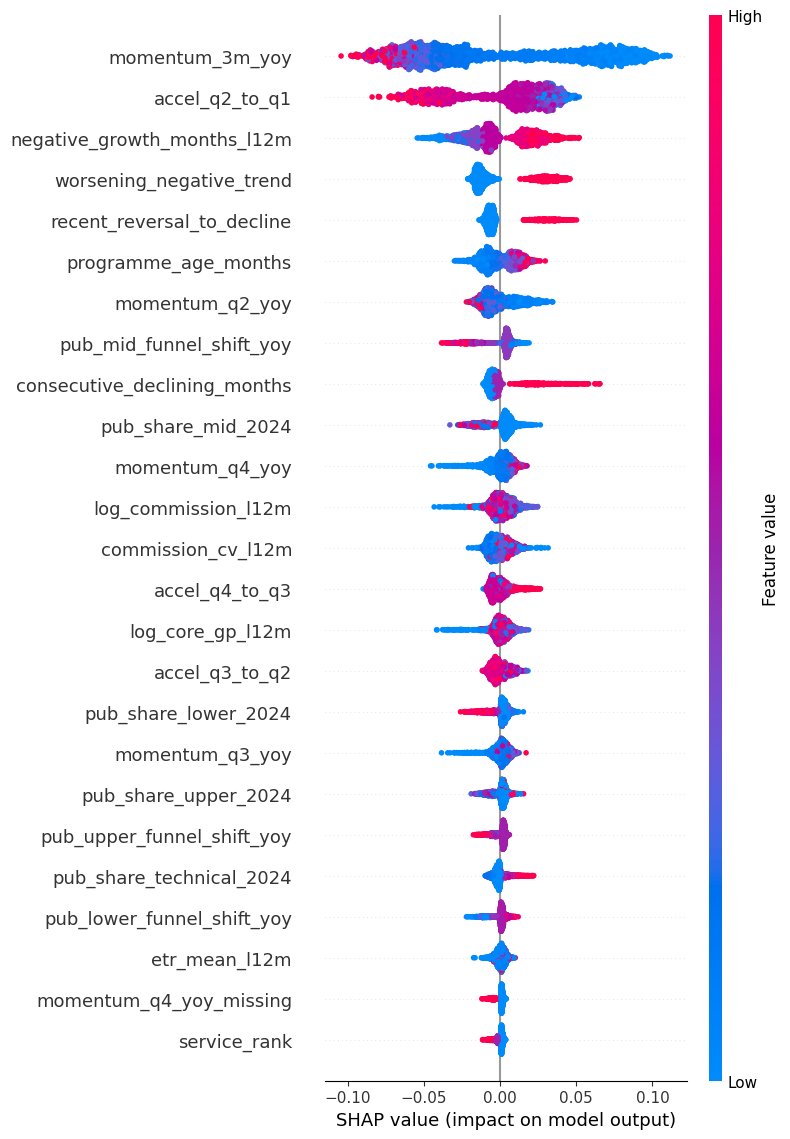


Top 15 features by SHAP importance:
                     feature  mean_abs_shap                  rfm_dimension
             momentum_3m_yoy       0.052482   momentum (recency/frequency)
              accel_q2_to_q1       0.028582   momentum (recency/frequency)
 negative_growth_months_l12m       0.018166   momentum (recency/frequency)
    worsening_negative_trend       0.018096   momentum (recency/frequency)
  recent_reversal_to_decline       0.010200   momentum (recency/frequency)
        programme_age_months       0.009313        firmographic/commercial
             momentum_q2_yoy       0.009099   momentum (recency/frequency)
    pub_mid_funnel_shift_yoy       0.008212 publisher (engagement breadth)
consecutive_declining_months       0.007996   momentum (recency/frequency)
          pub_share_mid_2024       0.007547 publisher (engagement breadth)
             momentum_q4_yoy       0.005821   momentum (recency/frequency)
         log_commission_l12m       0.005759        firmographic

In [48]:
full_model_rows = [r for r in results if r["model"].endswith("_full")]
best_full_label = max(full_model_rows, key=lambda r: r["gp_auc_roc"])["model"]

print(f"\nBest full model by GP-AUC: {best_full_label}")

best_model, best_feats = model_store[best_full_label]

import shap

explainer = shap.TreeExplainer(best_model)
shap_sample = test_df[best_feats].sample(min(2000, len(test_df)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)[:, :, 1]

plt.figure()
shap.summary_plot(shap_values, shap_sample, show=False, max_display=25)
plt.tight_layout()
plt.savefig(OUT_DIR / f"shap_summary_{best_full_label}.png", dpi=150, bbox_inches="tight")
plt.show()

importance = pd.Series(np.abs(shap_values).mean(axis=0), index=best_feats).sort_values(ascending=False)
importance_df = importance.reset_index()
importance_df.columns = ["feature", "mean_abs_shap"]

def classify_dimension(feature):
    if feature in MOMENTUM_FEATURES:
        return "momentum (recency/frequency)"
    if feature in PUBLISHER_FEATURES:
        return "publisher (engagement breadth)"
    return "firmographic/commercial"

importance_df["rfm_dimension"] = importance_df["feature"].apply(classify_dimension)

print("\nTop 15 features by SHAP importance:")
print(importance_df.head(15).to_string(index=False))

print("\nMean |SHAP| by RFM-adjacency dimension:")
dimension_summary = importance_df.groupby("rfm_dimension")["mean_abs_shap"].agg(["sum", "mean", "count"])
print(dimension_summary.sort_values("sum", ascending=False).round(4).to_string())

importance_df.to_csv(OUT_DIR / "shap_importance_ranked.csv", index=False)


### Permutation-importance check

Permutation importance provides a second, model-agnostic view of feature importance. Each feature is shuffled in the held-out test set and the resulting reduction in GP-weighted AUC is measured. This assesses whether the fitted model loses discrimination when that feature's information is removed.

The method is complementary to SHAP rather than an exact replication of it. Correlated features can substitute for one another, so disagreement between the rankings is possible even when both calculations are valid.

In [49]:
print("===STEP 3b: PERMUTATION IMPORTANCE (out-of-sample) vs SHAP===")

def classify_dimension_perm(f):
    if f in MOMENTUM_FEATURES:
        return "momentum (recency/frequency)"
    if f in PUBLISHER_FEATURES:
        return "publisher (engagement breadth)"
    return "firmographic/commercial"

def gp_auc_scorer(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, proba, sample_weight=w_eval_test)

perm_result = permutation_importance(
    best_model, test_df[best_feats], y_test,
    scoring=gp_auc_scorer, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature":              best_feats,
    "perm_importance_mean": perm_result.importances_mean,
    "perm_importance_std":  perm_result.importances_std,
}).sort_values("perm_importance_mean", ascending=False)
perm_df["rfm_dimension"] = perm_df["feature"].apply(classify_dimension_perm)
perm_df.to_csv(OUT_DIR / "permutation_importance_ranked.csv", index=False)

print(f"\nTop 15 features by permutation importance (GP-weighted AUC drop when shuffled, {best_full_label}):")
print(perm_df.head(15).round(4).to_string(index=False))

print(f"\nMean permutation importance by RFM-adjacency dimension:")
print(perm_df.groupby("rfm_dimension")["perm_importance_mean"].agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False).round(4).to_string())

shap_top10 = set(importance_df.head(10)["feature"])
perm_top10 = set(perm_df.head(10)["feature"])
overlap = shap_top10 & perm_top10
print(f"\nSHAP top-10 vs permutation top-10 overlap: {len(overlap)}/10 features")
print(f"  Features in both: {sorted(overlap)}")
print(f"  SHAP-only:  {sorted(shap_top10 - perm_top10)}")
print(f"  Perm-only:  {sorted(perm_top10 - shap_top10)}")


===STEP 3b: PERMUTATION IMPORTANCE (out-of-sample) vs SHAP===

Top 15 features by permutation importance (GP-weighted AUC drop when shuffled, rf_full):
                    feature  perm_importance_mean  perm_importance_std                  rfm_dimension
            momentum_3m_yoy                0.0509               0.0410   momentum (recency/frequency)
         pub_share_mid_2024                0.0227               0.0105 publisher (engagement breadth)
             accel_q2_to_q1                0.0224               0.0187   momentum (recency/frequency)
 pub_lower_funnel_shift_yoy                0.0094               0.0046 publisher (engagement breadth)
       pub_share_upper_2024                0.0085               0.0052 publisher (engagement breadth)
negative_growth_months_l12m                0.0052               0.0114   momentum (recency/frequency)
         commission_cv_l12m                0.0044               0.0051   momentum (recency/frequency)
   pub_share_technical_2024     

**Interpretation check:** only four of the SHAP top-ten features also appear in the permutation-importance top ten. I therefore would not treat either ranking as a definitive measure of individual feature importance. `momentum_3m_yoy`, `accel_q2_to_q1`, `negative_growth_months_l12m` and `pub_share_mid_2024` appearing in both gives more confidence that these features are contributing useful information.

## 10a. Alternative approach tested and rejected: ISCSL



In [50]:


ISCSL_ESS_TARGET = 0.10   # target: at least 10% of train n as effective sample size
ISCSL_CAP_PCT    = 0.99   # 99th-percentile cap, used only if raw/log don't clear the target
ISCSL_FIT_FLOOR  = 1.0    # floor so log1p / ratios behave for zero-GP clients

def effective_sample_size(w):
 
    w = np.asarray(w, dtype=float)
    return (w.sum() ** 2) / (w ** 2).sum()

def build_iscsl_weights(values, transform="raw", cap_pct=ISCSL_CAP_PCT):

    v = np.asarray(values, dtype=float)
    if transform == "raw":
        w = v
    elif transform == "cap":
        w = np.minimum(v, np.quantile(v, cap_pct))
    elif transform == "log":
        w = np.log1p(v)
    else:
        raise ValueError(transform)
    return w / w.mean()

print("ISCSL training-weight transform: ESS comparison (in-scope train set):")
gp_fit_base = train_df["core_gp_l12m"].clip(lower=ISCSL_FIT_FLOOR).values
ess_by_transform = {}
for t in ("raw", "cap", "log"):
    w = build_iscsl_weights(gp_fit_base, t)
    ess = effective_sample_size(w)
    ess_by_transform[t] = ess
    print(f"  {t:>4}:  ESS = {ess:8,.0f}  ({ess/len(w):5.1%} of n)  max weight = {w.max():.1f}")

iscsl_transform = next(
    (t for t in ("raw", "cap", "log") if ess_by_transform[t] / len(gp_fit_base) >= ISCSL_ESS_TARGET),
    "log",
)
print(f"\n-> selected transform: {iscsl_transform} "
      f"(first to clear the {ISCSL_ESS_TARGET:.0%} ESS target, fixed in advance)")

w_fit_iscsl = build_iscsl_weights(gp_fit_base, iscsl_transform)
print(f"w_fit_iscsl ESS: {effective_sample_size(w_fit_iscsl):,.0f} "
      f"({effective_sample_size(w_fit_iscsl)/len(w_fit_iscsl):.1%} of train n)")


ISCSL training-weight transform: ESS comparison (in-scope train set):
   raw:  ESS =      360  ( 4.9% of n)  max weight = 160.8
   cap:  ESS =      873  (11.8% of n)  max weight = 19.6
   log:  ESS =    6,687  (90.3% of n)  max weight = 2.0

-> selected transform: cap (first to clear the 10% ESS target, fixed in advance)
w_fit_iscsl ESS: 873 (11.8% of train n)


In [51]:
# Paired CV:

def fit_with_weight(est, X, y, w):
    if w is None:
        est.fit(X, y)
    elif isinstance(est, Pipeline):
        est.fit(X, y, clf__sample_weight=w)
    else:
        est.fit(X, y, sample_weight=w)
    return est

def compute_oof_weighted(label, X, y, w_fit):

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    for tr, va in skf.split(X, y):
        est = make_estimator(label, use_imputer=label.startswith("logistic"))
        w_tr = None if w_fit is None else w_fit[tr]
        fit_with_weight(est, X.iloc[tr], y[tr], w_tr)
        oof[va] = est.predict_proba(X.iloc[va])[:, 1]
    return oof

def paired_cv_scores(label, X, y, w_eval, w_fit_c, t_b, t_c, n_splits=N_SPLITS):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores_b, scores_c = [], []
    for tr, va in skf.split(X, y):
        est_b = make_estimator(label, use_imputer=label.startswith("logistic"))
        fit_with_weight(est_b, X.iloc[tr], y[tr], None)
        p_b = est_b.predict_proba(X.iloc[va])[:, 1]
        scores_b.append(f1_score(y[va], (p_b >= t_b).astype(int),
                                  sample_weight=w_eval[va], zero_division=0))

        est_c = make_estimator(label, use_imputer=label.startswith("logistic"))
        fit_with_weight(est_c, X.iloc[tr], y[tr], w_fit_c[tr])
        p_c = est_c.predict_proba(X.iloc[va])[:, 1]
        scores_c.append(f1_score(y[va], (p_c >= t_c).astype(int),
                                  sample_weight=w_eval[va], zero_division=0))
    return np.array(scores_b), np.array(scores_c)

def paired_bootstrap_ci(scores_b, scores_c, n=2000, seed=RANDOM_STATE):

    deltas = scores_c - scores_b
    mean_delta = deltas.mean()
    rng = np.random.default_rng(seed)
    boot = np.array([rng.choice(deltas, size=len(deltas), replace=True).mean() for _ in range(n)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return mean_delta, lo, hi, (lo <= 0 <= hi)

iscsl_verdicts = []
for algo in ["logistic_l1", "rf", "xgb"]:
    Xtr, Xte = train_df[FULL_FEATURES], test_df[FULL_FEATURES]

    # Arm B: unweighted fit (the standard approach used everywhere else here)
    oof_b = compute_oof_weighted(algo, Xtr, y_train, None)
    t_b, _, _ = tune_threshold(y_train, oof_b, w_eval_train)

    # Arm C: GP-weighted fit (ISCSL): the loss function itself is weighted by GP
    oof_c = compute_oof_weighted(algo, Xtr, y_train, w_fit_iscsl)
    t_c, _, _ = tune_threshold(y_train, oof_c, w_eval_train)

    sb, sc = paired_cv_scores(algo, Xtr, y_train, w_eval_train, w_fit_iscsl, t_b, t_c)
    mean_delta, lo, hi, crosses_zero = paired_bootstrap_ci(sb, sc)
    if crosses_zero:
        verdict = "no significant difference"
    elif mean_delta > 0:
        verdict = "ISCSL better"
    else:
        verdict = "ISCSL worse"

    iscsl_verdicts.append({
        "model": algo, "cv_mean_paired_delta": mean_delta,
        "cv_delta_ci_lo": lo, "cv_delta_ci_hi": hi, "verdict": verdict,
    })
    print(f"{algo:>12}: paired CV delta (ISCSL - unweighted) = {mean_delta:+.4f}  "
          f"95% CI [{lo:+.4f}, {hi:+.4f}]  ->  {verdict}")

iscsl_verdict_df = pd.DataFrame(iscsl_verdicts).round(4)
iscsl_verdict_df.to_csv(OUT_DIR / "iscsl_verdict_rerun.csv", index=False)
print("\n" + iscsl_verdict_df.to_string(index=False))


 logistic_l1: paired CV delta (ISCSL - unweighted) = -0.0223  95% CI [-0.0457, +0.0012]  ->  no significant difference
          rf: paired CV delta (ISCSL - unweighted) = +0.0014  95% CI [-0.0231, +0.0227]  ->  no significant difference
         xgb: paired CV delta (ISCSL - unweighted) = -0.0339  95% CI [-0.0562, -0.0080]  ->  ISCSL worse

      model  cv_mean_paired_delta  cv_delta_ci_lo  cv_delta_ci_hi                   verdict
logistic_l1               -0.0223         -0.0457          0.0012 no significant difference
         rf                0.0014         -0.0231          0.0227 no significant difference
        xgb               -0.0339         -0.0562         -0.0080               ISCSL worse


## 11. Reduced model using three-month momentum only

The same three algorithms are fitted using only the three-month year-on-year momentum field and its missing-value indicator. This isolates the value obtained from fitting and thresholding the strongest individual signal from the incremental value of the wider feature set.

A simple rule based on whether three-month momentum is negative is also included as an unfitted comparison.

In [52]:
print("===STEP 4: REDUCED MODEL (3M-YoY only, in-scope population)===")

for model_name, algo in model_specs:
    label = f"{model_name}_3m_only"
    Xtr, Xte = train_df[REDUCED_FEATURES_3M_ONLY], test_df[REDUCED_FEATURES_3M_ONLY]

    est = make_estimator(algo, use_imputer=(algo == "logistic"))
    est.fit(Xtr, y_train)
    proba_te = est.predict_proba(Xte)[:, 1]
    oof = compute_oof(algo, Xtr, y_train)
    t, _, _ = tune_threshold(y_train, oof, w_eval_train)

    row = evaluate(y_test, (proba_te >= t).astype(int), proba_te, w_eval_test,
                   algo, round(float(t), 2), label)
    results.append(row)
    model_store[label] = (est, REDUCED_FEATURES_3M_ONLY)

    cv_m, cv_s = cv_fold_scores(algo, Xtr, y_train, w_eval_train, t)
    print(f"  {label:>20}: GP-F1={row['gp_f1']:.4f}  thr={t:.2f}  "
          f"gp_auc={row['gp_auc_roc']:.3f}  CV={cv_m:.4f}±{cv_s:.4f}")

b2_pred = (test_df["momentum_3m_yoy"] < 0).astype(int).values
results.append(evaluate(y_test, b2_pred, None, w_eval_test, "rule", "rule", "baseline_3m_yoy_rule"))


===STEP 4: REDUCED MODEL (3M-YoY only, in-scope population)===
   logistic_l1_3m_only: GP-F1=0.6220  thr=0.50  gp_auc=0.592  CV=0.6287±0.0443
            rf_3m_only: GP-F1=0.6248  thr=0.30  gp_auc=0.600  CV=0.6267±0.0419
           xgb_3m_only: GP-F1=0.6210  thr=0.35  gp_auc=0.617  CV=0.6263±0.0477


## 12. Headline model comparison

The comparison table brings together the current 12-month rule, the unfitted three-month rule, the fitted three-month models and the full models. GP-weighted F1 measures classification performance at the selected threshold. GP-weighted AUC measures the quality of the overall risk ranking.

The same selected full model is used from this point onwards for interpretation, the risk bands, confusion matrices and the downstream pricing outputs.


In [53]:
res_df = pd.DataFrame(results).round(4)
res_df.to_csv(OUT_DIR / "model_comparison_full_vs_reduced.csv", index=False)


print("HEADLINE COMPARISON (in-scope population): 12M rule vs full model vs 3M-only")

print(res_df[["model", "algo", "threshold", "gp_precision", "gp_recall",
             "gp_f1", "gp_auc_roc"]].to_string(index=False))

best_full_f1   = [r for r in results if r["model"] == best_full_label][0]["gp_f1"]
best_full_auc  = [r for r in results if r["model"] == best_full_label][0]["gp_auc_roc"]
best_3m_fit_f1 = max(r["gp_f1"] for r in results if r["model"].endswith("_3m_only"))
rule_12m_f1    = [r for r in results if r["model"] == "baseline_12m_yoy"][0]["gp_f1"]
rule_3m_f1     = [r for r in results if r["model"] == "baseline_3m_yoy_rule"][0]["gp_f1"]

print(f"\nGP-F1 summary (in-scope population):")
print(f"  12M-YoY rule (current method):  {rule_12m_f1:.4f}")
print(f"  3M-YoY rule (naive, unfitted):   {rule_3m_f1:.4f}")
print(f"  3M-YoY, fitted in a model:       {best_3m_fit_f1:.4f}")
print(f"  Full model ({len(FULL_FEATURES)} features, {best_full_label}):  "
      f"GP-F1={best_full_f1:.4f}  GP-AUC={best_full_auc:.4f}")
print(f"\n  Full model improvement over 12M rule:  {best_full_f1 - rule_12m_f1:+.4f}")
if (best_full_f1 - rule_12m_f1) > 0:
    print(f"  3M-fitted recovers {(best_3m_fit_f1 - rule_12m_f1) / (best_full_f1 - rule_12m_f1) * 100:.0f}% "
          f"of that improvement")


HEADLINE COMPARISON (in-scope population): 12M rule vs full model vs 3M-only
               model          algo threshold  gp_precision  gp_recall  gp_f1  gp_auc_roc
    baseline_12m_yoy business rule       n/a        0.5105     0.3508 0.4158         NaN
    logistic_l1_full      logistic      0.33        0.4366     0.7920 0.5629      0.5669
             rf_full            rf      0.36        0.4823     0.8933 0.6264      0.6380
            xgb_full           xgb      0.23        0.4743     0.9539 0.6336      0.5963
 logistic_l1_3m_only      logistic       0.5        0.4522     0.9958 0.6220      0.5918
          rf_3m_only            rf       0.3        0.4637     0.9575 0.6248      0.5999
         xgb_3m_only           xgb      0.35        0.4558     0.9741 0.6210      0.6174
baseline_3m_yoy_rule          rule      rule        0.4803     0.4443 0.4616         NaN

GP-F1 summary (in-scope population):
  12M-YoY rule (current method):  0.4158
  3M-YoY rule (naive, unfitted):   0.4616
 

**Result:** most of the improvement over the existing 12-month rule comes from using recent three-month momentum rather than from the wider feature set. The fitted three-month Random Forest reaches a GP-F1 of 0.6248 compared with 0.6264 for the full model, recovering around 99% of the improvement over the existing rule.

This means the value of the full model should not be judged only from the headline F1 score. I look at the types of errors it makes next, as these have different implications for the pricing decision.

## 13. Fallback model for established sparse programmes

Established programmes without a calculable three-month momentum value are modelled separately using features that do not require the missing year-on-year comparator. Random Forest and XGBoost are compared using the same threshold-selection process.

This population is small, so its results are treated as directional rather than equivalent in strength to the primary-model evaluation.

In [54]:
print("====STEP 5: FALLBACK MODEL====")

fb_train, fb_test = train_test_split(
    df_fallback, test_size=TEST_SIZE, stratify=df_fallback[TARGET], random_state=RANDOM_STATE
)
fb_y_train = fb_train[TARGET].values
fb_y_test  = fb_test[TARGET].values
fb_w_train = build_weights(fb_train["core_gp_l12m"].values)
fb_w_test  = build_weights(fb_test["core_gp_l12m"].values)

print(f"Fallback train: {len(fb_train):,}  test: {len(fb_test):,}  "
      f"(decline rate {df_fallback[TARGET].mean():.1%})")

fallback_results = []
for model_name, algo in [("rf", "rf"), ("xgb", "xgb")]:
    Xtr, Xte = fb_train[FALLBACK_FEATURES], fb_test[FALLBACK_FEATURES]
    est = make_estimator(algo)
    est.fit(Xtr, fb_y_train)
    proba_te = est.predict_proba(Xte)[:, 1]
    oof = compute_oof(algo, Xtr, fb_y_train)
    t, _, _ = tune_threshold(fb_y_train, oof, fb_w_train)
    row = evaluate(fb_y_test, (proba_te >= t).astype(int), proba_te, fb_w_test,
                   algo, round(float(t), 2), f"fallback_{model_name}")
    fallback_results.append(row)
    model_store[f"fallback_{model_name}"] = (est, FALLBACK_FEATURES)
    print(f"  fallback_{model_name:>6}: GP-F1={row['gp_f1']:.4f}  thr={t:.2f}  "
          f"gp_auc={row['gp_auc_roc']:.3f}  gp_recall={row['gp_recall']:.3f}  "
          f"gp_precision={row['gp_precision']:.3f}")

pd.DataFrame(fallback_results).round(4).to_csv(OUT_DIR / "fallback_model_results.csv", index=False)
best_fallback = max(fallback_results, key=lambda r: r["gp_f1"])
print(f"\n  Best fallback model: {best_fallback['model']}  GP-F1={best_fallback['gp_f1']:.4f}  "
      f"gp_auc={best_fallback['gp_auc_roc']:.3f}")


====STEP 5: FALLBACK MODEL====
Fallback train: 331  test: 143  (decline rate 44.5%)
  fallback_    rf: GP-F1=0.4217  thr=0.34  gp_auc=0.452  gp_recall=0.773  gp_precision=0.290
  fallback_   xgb: GP-F1=0.5063  thr=0.20  gp_auc=0.738  gp_recall=0.999  gp_precision=0.339

  Best fallback model: fallback_xgb  GP-F1=0.5063  gp_auc=0.738


## Result
The volume is very small and therefore although this can be taken as a directrional finding, it is too small of a part of the overall client base.

## 14. Creating the risk bands

The selected full model's test probabilities are grouped into 10-percentage-point bands. For each band, the table reports the observed decline rate, client count, Core GP, Tracking GP and average decline severity.

This provides a calibration and ranking diagnostic for the classifier. The final pricing notebooks recreate their own training-based OOF risk bands rather than using these test-set bands directly.

In [55]:
calib_model, calib_feats = model_store[best_full_label]
proba_te = calib_model.predict_proba(test_df[calib_feats])[:, 1]

calib_df = pd.DataFrame({
    "risk_score":     proba_te,
    "actual_decline": y_test,
    "commission":     test_df["commission_l12m"].values,
    "core_gp":        test_df["core_gp_l12m"].values,
    "tracking_gp":    test_df["tracking_gp_l12m"].values,
    "actual_change_pct": (
        (test_df["commission_forward_12m"] - test_df["commission_l12m"])
        / test_df["commission_l12m"]
    ).values,
})

bins   = np.arange(0, 1.01, 0.10)
labels = [f"{int(b*100)}-{int((b+0.10)*100)}%" for b in bins[:-1]]
calib_df["band"] = pd.cut(calib_df["risk_score"], bins=bins, labels=labels, include_lowest=True)

calibration_summary = calib_df.groupby("band", observed=True).apply(
    lambda g: pd.Series({
        "account_count":       len(g),
        "actual_declines":     g["actual_decline"].sum(),
        "actual_decline_rate": g["actual_decline"].mean(),
        "total_core_gp":       g["core_gp"].sum(),
        "total_tracking_gp":   g["tracking_gp"].sum(),
        "mean_severity_among_decliners": (
            g.loc[g["actual_decline"] == 1, "actual_change_pct"].mean()
            if g["actual_decline"].sum() > 0 else np.nan
        ),
    })
).reset_index()

calibration_summary["gp_share"] = (
    calibration_summary["total_core_gp"] / calibration_summary["total_core_gp"].sum()
)
band_midpoints = {labels[i]: (bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)}
calibration_summary["risk_band_midpoint"] = calibration_summary["band"].map(band_midpoints)

print(f"\nCalibration table ")
print(calibration_summary.round(4).to_string(index=False))
calibration_summary.to_csv(OUT_DIR / "calibration_table_for_arr.csv", index=False)



Calibration table 
  band  account_count  actual_declines  actual_decline_rate  total_core_gp  total_tracking_gp  mean_severity_among_decliners  gp_share risk_band_midpoint
20-30%          110.0             33.0               0.3000   1.920238e+06       1.694606e+06                        -0.4274    0.0504               0.25
30-40%          571.0            193.0               0.3380   1.097775e+07       9.927545e+06                        -0.4397    0.2883               0.35
40-50%          913.0            391.0               0.4283   1.424609e+07       1.295690e+07                        -0.4614    0.3741               0.45
50-60%          726.0            416.0               0.5730   6.223239e+06       5.930055e+06                        -0.5120    0.1634               0.55
60-70%          621.0            401.0               0.6457   3.512635e+06       3.368093e+06                        -0.6189    0.0922               0.65
70-80%          228.0            176.0               0.7

Decline rates increase as the model risk score increases, which is what I would expect if the ranking is useful. The highest 80–90% band contains only five clients and almost no GP, so I would not draw a strong conclusion from that band on its own.

### Risk-band chart

The chart compares each band's risk-score midpoint with its realised decline rate. Point size represents the band's share of Core GP and the annotation reports both GP share and client count. The diagonal line is a reference for perfect agreement between predicted and observed risk.

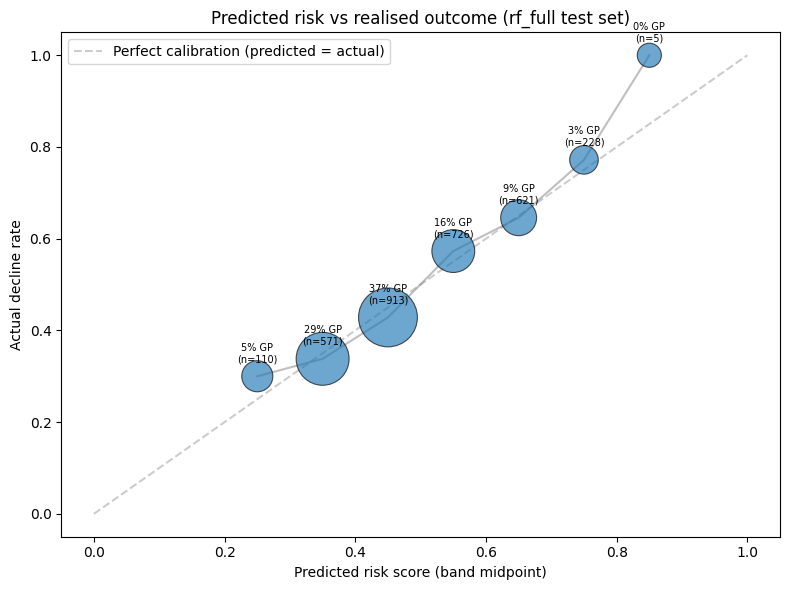

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

sizes = 300 + 4000 * calibration_summary["gp_share"]                               
ax.scatter(
    calibration_summary["risk_band_midpoint"], calibration_summary["actual_decline_rate"],
    s=sizes, alpha=0.65, edgecolor="black", linewidth=0.8, zorder=3,
)
ax.plot(
    calibration_summary["risk_band_midpoint"], calibration_summary["actual_decline_rate"],
    linestyle="-", color="grey", alpha=0.5, zorder=2,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.4, zorder=1,
        label="Perfect calibration (predicted = actual)")

for _, row in calibration_summary.iterrows():
    ax.annotate(
        f"{row['gp_share']:.0%} GP\n(n={int(row['account_count'])})",
        (row["risk_band_midpoint"], row["actual_decline_rate"]),
        textcoords="offset points", xytext=(0, 10), ha="center", fontsize=7,
    )

ax.set_xlabel("Predicted risk score (band midpoint)")
ax.set_ylabel("Actual decline rate")
ax.set_title(f"Predicted risk vs realised outcome ({best_full_label} test set)")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUT_DIR / f"calibration_chart_{best_full_label}.png", dpi=150)
plt.show()



## 15. Classification outcomes in client and GP terms

Confusion matrices are produced for the existing 12-month rule, the best fitted three-month model and the selected full model. Each matrix reports:

- true positives: flagged clients that subsequently declined;
- false positives: flagged clients that did not decline;
- false negatives: unflagged clients that subsequently declined; and
- true negatives: unflagged clients that did not decline.

Both client counts and Core GP totals are shown because the commercial cost of an error depends on client value as well as the number of clients affected.

I compare the current 12-month rule, the best fitted three-month model and the selected full model because these represent the main practical alternatives: the current process, a simple momentum-based model and the wider feature model.

I show both client counts and GP because the same number of classification errors can have very different commercial importance depending on the clients involved.


In [ ]:
def confusion_matrix_report(pred, actual, gp, label, threshold_note=""):
    cells = {
        "true_positive":  (pred == 1) & (actual == 1),
        "false_positive": (pred == 1) & (actual == 0),
        "false_negative": (pred == 0) & (actual == 1),
        "true_negative":  (pred == 0) & (actual == 0),
    }
    total_clients = len(actual)
    total_gp = gp.sum()

    rows = []
    for name, mask in cells.items():
        n = mask.sum()
        gp_total = gp[mask].sum()
        rows.append({
            "model": label, "cell": name,
            "client_count": int(n), "client_share": n / total_clients,
            "gp_total": gp_total, "gp_share": gp_total / total_gp,
        })
    df = pd.DataFrame(rows).set_index("cell")

    tp_n, fp_n = df.loc["true_positive", "client_count"], df.loc["false_positive", "client_count"]
    fn_n = df.loc["false_negative", "client_count"]
    tp_gp, fp_gp = df.loc["true_positive", "gp_total"], df.loc["false_positive", "gp_total"]
    fn_gp = df.loc["false_negative", "gp_total"]

    raw_precision = tp_n / (tp_n + fp_n) if (tp_n + fp_n) > 0 else np.nan
    raw_recall    = tp_n / (tp_n + fn_n) if (tp_n + fn_n) > 0 else np.nan
    raw_f1        = 2 * raw_precision * raw_recall / (raw_precision + raw_recall) if (raw_precision + raw_recall) > 0 else np.nan
    gp_precision  = tp_gp / (tp_gp + fp_gp) if (tp_gp + fp_gp) > 0 else np.nan
    gp_recall     = tp_gp / (tp_gp + fn_gp) if (tp_gp + fn_gp) > 0 else np.nan
    gp_f1         = 2 * gp_precision * gp_recall / (gp_precision + gp_recall) if (gp_precision + gp_recall) > 0 else np.nan

    print(f"\n--- {label} {threshold_note}---")
    for name in ["true_positive", "false_positive", "false_negative", "true_negative"]:
        r = df.loc[name]
        print(f"  {name:>16}: {int(r['client_count']):>5,} clients ({r['client_share']:.1%})   "
              f"€{r['gp_total']:>14,.0f} GP ({r['gp_share']:.1%})")
    print(f"  Raw (client-count):  precision={raw_precision:.4f}  recall={raw_recall:.4f}  f1={raw_f1:.4f}")
    print(f"  GP-weighted:         precision={gp_precision:.4f}  recall={gp_recall:.4f}  f1={gp_f1:.4f}")

    summary_row = {
        "model": label,
        "raw_precision": raw_precision, "raw_recall": raw_recall, "raw_f1": raw_f1,
        "gp_precision": gp_precision, "gp_recall": gp_recall, "gp_f1": gp_f1,
    }
    return df.reset_index(), summary_row

print("===CONFUSION MATRICES: 12M rule vs fitted 3M-YoY vs full model===")

cm_test_gp = test_df["core_gp_l12m"].clip(lower=0).values

cm_detail_rule, cm_summary_rule = confusion_matrix_report(
    b1_pred, y_test, cm_test_gp, "baseline_12m_yoy"
)

best_3m_label = max(
    [r for r in results if r["model"].endswith("_3m_only")], key=lambda r: r["gp_f1"]
)["model"]
cm_3m_model, cm_3m_feats = model_store[best_3m_label]
cm_3m_threshold = [r for r in results if r["model"] == best_3m_label][0]["threshold"]
cm_3m_proba = cm_3m_model.predict_proba(test_df[cm_3m_feats])[:, 1]
cm_3m_pred = (cm_3m_proba >= cm_3m_threshold).astype(int)
cm_detail_3m, cm_summary_3m = confusion_matrix_report(
    cm_3m_pred, y_test, cm_test_gp, best_3m_label, f"(threshold={cm_3m_threshold:.2f}) "
)

cm_model, cm_feats = model_store[best_full_label]
cm_threshold = full_thresholds.get(best_full_label.split("_")[0], 0.5)
cm_proba = cm_model.predict_proba(test_df[cm_feats])[:, 1]
cm_pred = (cm_proba >= cm_threshold).astype(int)
cm_detail_full, cm_summary_full = confusion_matrix_report(
    cm_pred, y_test, cm_test_gp, best_full_label, f"(threshold={cm_threshold:.2f}) "
)

cm_all_detail = pd.concat([cm_detail_rule, cm_detail_3m, cm_detail_full], ignore_index=True)
cm_all_detail.to_csv(OUT_DIR / "confusion_matrix_counts_and_gp.csv", index=False)

cm_summary_df = pd.DataFrame([cm_summary_rule, cm_summary_3m, cm_summary_full])
cm_summary_df.to_csv(OUT_DIR / "confusion_matrix_precision_recall_f1.csv", index=False)

print(f"\n--- Side by side: raw vs GP-weighted precision/recall/F1 ---")
print(cm_summary_df.round(4).to_string(index=False))


===CONFUSION MATRICES: 12M rule vs fitted 3M-YoY vs full model===

--- baseline_12m_yoy ---
     true_positive:   888 clients (28.0%)   €     6,024,359 GP (15.8%)
    false_positive:   713 clients (22.5%)   €     5,777,027 GP (15.2%)
    false_negative:   727 clients (22.9%)   €    11,148,826 GP (29.3%)
     true_negative:   846 clients (26.7%)   €    15,128,835 GP (39.7%)
  Raw (client-count):  precision=0.5547  recall=0.5498  f1=0.5522
  GP-weighted:         precision=0.5105  recall=0.3508  f1=0.4158

--- rf_3m_only (threshold=0.30) ---
     true_positive: 1,517 clients (47.8%)   €    16,443,811 GP (43.2%)
    false_positive: 1,411 clients (44.5%)   €    19,020,637 GP (50.0%)
    false_negative:    98 clients (3.1%)   €       729,374 GP (1.9%)
     true_negative:   148 clients (4.7%)   €     1,885,225 GP (5.0%)
  Raw (client-count):  precision=0.5181  recall=0.9393  f1=0.6678
  GP-weighted:         precision=0.4637  recall=0.9575  f1=0.6248

--- rf_full (threshold=0.36) ---
     true

**Error mix:** the full and three-month models have very similar overall GP-F1 scores, but they do not make the same errors. Compared with the fitted three-month model, the full model produces 117 fewer false-positive clients and around €2.56m less false-positive GP. This comes at the cost of around €1.10m additional false-negative GP.

This distinction matters for the pricing stage because incorrectly treating a non-declining client as high risk can also have a commercial cost. I therefore do not treat the small difference in headline F1 as the whole model comparison.

## 16. Export predictions for the pricing backtest

The fitted test-set probabilities and classifications are exported for both the selected full model and the best three-month-only model. Reusing the predictions generated in this notebook ensures that the pricing backtest is based on the same model run as the reported confusion matrices.

In [58]:
export_cols = ["EffectiveBusinessUnit", "core_gp_l12m"]  # no client-identifying columns - AdvertiserGroup deliberately excluded

test_outcome_full = test_df[export_cols].copy()
test_outcome_full["actual_decline"]    = y_test
test_outcome_full["predicted_proba"]   = cm_proba
test_outcome_full["predicted_decline"] = cm_pred
test_outcome_full["model"]             = best_full_label
test_outcome_full["threshold"]         = cm_threshold
test_outcome_full.to_csv(OUT_DIR / "test_classification_outcome_full.csv", index=False)

test_outcome_3m = test_df[export_cols].copy()
test_outcome_3m["actual_decline"]    = y_test
test_outcome_3m["predicted_proba"]   = cm_3m_proba
test_outcome_3m["predicted_decline"] = cm_3m_pred
test_outcome_3m["model"]             = best_3m_label
test_outcome_3m["threshold"]         = cm_3m_threshold
test_outcome_3m.to_csv(OUT_DIR / "test_classification_outcome_3monly.csv", index=False)

print(f"\nExported test-set classification outcomes for merging with the pricing backtest:")
print(f"  test_classification_outcome_full.csv    ({best_full_label}, threshold={cm_threshold:.2f})")
print(f"  test_classification_outcome_3monly.csv  ({best_3m_label}, threshold={cm_3m_threshold:.2f})")



Exported test-set classification outcomes for merging with the pricing backtest:
  test_classification_outcome_full.csv    (rf_full, threshold=0.36)
  test_classification_outcome_3monly.csv  (rf_3m_only, threshold=0.30)


## 17. Sensitivity checks

### Fields without historical point-in-time values

Platform rank, service rank and exclusivity are available as current snapshots rather than reconstructable historical values. The full tree models are refitted without these fields and the change in GP-weighted F1 is reported. This tests whether the main result depends materially on the known point-in-time limitation.

In [59]:
print("STEP 7 - SENSITIVITY: point-in-time limitation check")
print(f"Fields with no dated history (accepted limitation): {UNDATEABLE_FIELDS}")

FEATURES_NO_UNDATEABLE = [f for f in FULL_FEATURES if f not in UNDATEABLE_FIELDS]

for model_name, algo in [("rf", "rf"), ("xgb", "xgb")]:
    Xtr, Xte = train_df[FEATURES_NO_UNDATEABLE], test_df[FEATURES_NO_UNDATEABLE]
    est = make_estimator(algo)
    est.fit(Xtr, y_train)
    proba_te = est.predict_proba(Xte)[:, 1]
    oof = compute_oof(algo, Xtr, y_train)
    t, _, _ = tune_threshold(y_train, oof, w_eval_train)
    row = evaluate(y_test, (proba_te >= t).astype(int), proba_te, w_eval_test,
                   algo, round(float(t), 2), f"{model_name}_no_undateable")
    full_row = [r for r in results if r["model"] == f"{model_name}_full"][0]
    gap = full_row["gp_f1"] - row["gp_f1"]
    print(f"  {model_name}: full={full_row['gp_f1']:.4f}  "
          f"no_undateable={row['gp_f1']:.4f}  gap={gap:+.4f}  "
          f"({'material' if abs(gap) > 0.02 else 'small'}.. "
          f"{'' if gap > 0.02 else 'limited sensitivity, gap is small'})")


STEP 7 - SENSITIVITY: point-in-time limitation check
Fields with no dated history (accepted limitation): ['platform_rank', 'service_rank', 'is_exclusive']
  rf: full=0.6264  no_undateable=0.6232  gap=+0.0033  (small.. limited sensitivity, gap is small)
  xgb: full=0.6336  no_undateable=0.5784  gap=+0.0551  (material.. )


### Quarter-to-quarter acceleration features

The tree models are refitted without the three acceleration measures. This ablation test complements feature-importance results by measuring the change in held-out performance when the features are removed together.

In [60]:
print("===SENSITIVITY: quarter-to-quarter acceleration features===")

ACCEL_FIELDS = ["accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3"]
FEATURES_NO_ACCEL = [f for f in FULL_FEATURES if f not in ACCEL_FIELDS]
print(f"Dropping: {ACCEL_FIELDS}")

for model_name, algo in [("rf", "rf"), ("xgb", "xgb")]:
    Xtr, Xte = train_df[FEATURES_NO_ACCEL], test_df[FEATURES_NO_ACCEL]
    est = make_estimator(algo)
    est.fit(Xtr, y_train)
    proba_te = est.predict_proba(Xte)[:, 1]
    oof = compute_oof(algo, Xtr, y_train)
    t, _, _ = tune_threshold(y_train, oof, w_eval_train)
    row = evaluate(y_test, (proba_te >= t).astype(int), proba_te, w_eval_test,
                   algo, round(float(t), 2), f"{model_name}_no_accel")
    full_row = [r for r in results if r["model"] == f"{model_name}_full"][0]
    gap = full_row["gp_f1"] - row["gp_f1"]
    print(f"  {model_name}: full={full_row['gp_f1']:.4f}  "
          f"no_accel={row['gp_f1']:.4f}  gap={gap:+.4f}  "
          f"({'material' if abs(gap) > 0.02 else 'small'} - "
          f"{'acceleration features are earning their place' if gap > 0.02 else 'limited standalone lift once everything else is already in the model'})")


===SENSITIVITY: quarter-to-quarter acceleration features===
Dropping: ['accel_q2_to_q1', 'accel_q3_to_q2', 'accel_q4_to_q3']
  rf: full=0.6264  no_accel=0.6243  gap=+0.0022  (small - limited standalone lift once everything else is already in the model)
  xgb: full=0.6336  no_accel=0.5930  gap=+0.0406  (material - acceleration features are earning their place)


For Random Forest, removing all three acceleration measures reduces GP-F1 by only 0.0022. This is small even though `accel_q2_to_q1` ranks highly in the SHAP analysis. I interpret this as a reminder that importance within the fitted model is not necessarily the same as unique incremental predictive value, particularly where features contain overlapping information.

## 18. Out-of-time evaluation

The selected model is applied to observations from April 2025 onwards using the same feature definitions and scope rules as the January dataset.

These observations were not used for model fitting or threshold selection, so I use the result as a check of temporal stability. However, the rolling panel can contain the same advertiser at multiple observation months, so this should not be interpreted as a completely independent client-level test set.


In [61]:
print("===STEP 8: OUT-OF-TIME CHECK ===")

oot_panel = pd.read_csv(OOT_PATH, low_memory=False)
oot_panel["ObservationMonth"] = pd.to_datetime(oot_panel["ObservationMonth"])
oot = oot_panel[oot_panel["ObservationMonth"] >= OOT_CUTOFF].copy()

oot = oot[oot["commission_l12m"] > 0].copy()
oot["log_commission_l12m"] = np.log1p(oot["commission_l12m"].clip(lower=0))
oot["log_core_gp_l12m"]    = np.log1p(oot["core_gp_l12m"].clip(lower=0))
oot["commission_size_tier"]      = pd.cut(oot["commission_l12m"], bins=tier_bins, labels=tier_labels)
oot["commission_size_tier_code"] = oot["commission_size_tier"].cat.codes
oot["momentum_3m_yoy_missing"] = oot["momentum_3m_yoy"].isna().astype(int)
oot["momentum_3m_yoy"]         = oot["momentum_3m_yoy"].fillna(0)
oot["commission_cv_l12m"]        = oot["commission_cv_l12m"].fillna(0)
oot["fixed_fee_share_mean_l12m"] = oot["fixed_fee_share_mean_l12m"].fillna(0)
oot["programme_age_months"]      = oot["programme_age_months"].fillna(oot["programme_age_months"].median())
oot["etr_mean_l12m"]             = oot["etr_mean_l12m"].fillna(oot["etr_mean_l12m"].median())
for col in ["momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    oot[f"{col}_missing"] = oot[col].isna().astype("int8")
if "accel_q2_to_q1" not in oot.columns:
    oot["accel_q2_to_q1"] = oot["momentum_q1_yoy"] - oot["momentum_q2_yoy"]
if "accel_q3_to_q2" not in oot.columns:
    oot["accel_q3_to_q2"] = oot["momentum_q2_yoy"] - oot["momentum_q3_yoy"]
if "accel_q4_to_q3" not in oot.columns:
    oot["accel_q4_to_q3"] = oot["momentum_q3_yoy"] - oot["momentum_q4_yoy"]
for c in ["accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
          "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    oot[c] = oot[c].fillna(0)
q1_oot, yoy_oot = oot["momentum_q1_yoy"], oot["commission_yoy_growth"]
oot["worsening_negative_trend"] = (
    q1_oot.notna() & yoy_oot.notna() & (q1_oot < 0) & (yoy_oot < 0) & (q1_oot < yoy_oot)
).astype("int8")
oot["recent_reversal_to_decline"] = (
    q1_oot.notna() & yoy_oot.notna() & (q1_oot < 0) & (yoy_oot >= 0)
).astype("int8")
for col in PUBLISHER_FEATURES:
    if col not in oot.columns:
        oot[col] = 0
    oot[col] = oot[col].fillna(0)

oot = oot[oot[TARGET].notna()].copy()
oot[TARGET] = oot[TARGET].astype(int)

oot["scope_segment"] = np.select(
    [
        oot["momentum_3m_yoy_missing"] == 0,
        (oot["momentum_3m_yoy_missing"] == 1) & (oot["programme_age_months"] < YOUNG_THRESHOLD_MONTHS),
        (oot["momentum_3m_yoy_missing"] == 1) & (oot["programme_age_months"] >= YOUNG_THRESHOLD_MONTHS),
    ],
    ["in_scope", "excluded_too_young", "fallback_established_sparse"],
    default="unclassified",
)
oot_in_scope = oot[oot["scope_segment"] == "in_scope"].copy()

w_oot = build_weights(oot_in_scope["core_gp_l12m"].values)
proba_oot = calib_model.predict_proba(oot_in_scope[calib_feats])[:, 1]
t_final = full_thresholds.get(best_full_label.split("_")[0], 0.5)
oot_row = evaluate(oot_in_scope[TARGET].values, (proba_oot >= t_final).astype(int), proba_oot,
                   w_oot, "oot", t_final, f"{best_full_label}_OOT")
print(f"  {len(oot_in_scope):,} out-of-time in-scope rows "
      f"({oot_in_scope[TARGET].mean():.1%} decline)")
print(f"  In-sample test GP-F1:  {best_full_f1:.4f}")
print(f"  Out-of-time GP-F1:     {oot_row['gp_f1']:.4f}")
print(f"  {'Generalises well' if abs(best_full_f1 - oot_row['gp_f1']) < 0.05 else 'Notable drift: investigate'}")
pd.DataFrame([oot_row]).to_csv(OUT_DIR / "out_of_time_check.csv", index=False)


===STEP 8: OUT-OF-TIME CHECK ===
  31,560 out-of-time in-scope rows (50.4% decline)
  In-sample test GP-F1:  0.6264
  Out-of-time GP-F1:     0.6389
  Generalises well


The out-of-time GP-F1 is 0.6389 compared with 0.6264 on the original held-out test set. I therefore do not see evidence of model performance failing or changing over this later period, although I treat this as a stability check rather than proof of future generalisation.

## Appendix A. Risk-ranking diagnostic

The calibration table and lift curve summarise the same risk ranking in different ways. This diagnostic reports the realised decline rate among the highest-ranked proportions of the test set and compares these values with the overall GP-weighted decline rate and the highest empirical risk bands.

In [62]:
print("DIAGNOSTIC: lift curve vs calibration table reconciliation"
      f"({best_full_label}))")

diag_proba = calib_model.predict_proba(test_df[calib_feats])[:, 1]
diag_df = pd.DataFrame({
    "risk_score": diag_proba,
    "actual_decline": y_test,
    "core_gp": test_df["core_gp_l12m"].clip(lower=0).values,
})
diag_df = diag_df.sort_values("risk_score", ascending=False).reset_index(drop=True)
diag_df["pop_share"] = (diag_df.index + 1) / len(diag_df)

print(f"\nGP-weighted decline rate for the TOP-RANKED X% of test clients "
      f"(by predicted risk, highest first):")
print(f"{'top_pct':>10}  {'n':>6}  {'gp_weighted_decline_rate':>26}  {'unweighted_decline_rate':>24}")
for top_pct in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    cut = int(np.ceil(top_pct * len(diag_df)))
    sub = diag_df.iloc[:cut]
    gp_rate = (sub["core_gp"] * sub["actual_decline"]).sum() / sub["core_gp"].sum()
    uw_rate = sub["actual_decline"].mean()
    print(f"{top_pct:>10.0%}  {cut:>6}  {gp_rate:>26.3f}  {uw_rate:>24.3f}")

overall_gp_rate = (diag_df["core_gp"] * diag_df["actual_decline"]).sum() / diag_df["core_gp"].sum()
print(f"\n  Overall GP-weighted decline rate (whole test set): {overall_gp_rate:.3f}")


print(f"\nFor direct comparison, calibration table top bands were:")
top_calib = calibration_summary.sort_values("risk_band_midpoint", ascending=False).head(3)
print(top_calib[["band", "account_count", "actual_decline_rate", "gp_share"]].to_string(index=False))


DIAGNOSTIC: lift curve vs calibration table reconciliation(rf_full))

GP-weighted decline rate for the TOP-RANKED X% of test clients (by predicted risk, highest first):
   top_pct       n    gp_weighted_decline_rate   unweighted_decline_rate
        5%     159                       0.895                     0.830
       10%     318                       0.858                     0.761
       20%     635                       0.808                     0.713
       30%     953                       0.765                     0.679
       40%    1270                       0.758                     0.653
       50%    1587                       0.600                     0.631

  Overall GP-weighted decline rate (whole test set): 0.451

For direct comparison, calibration table top bands were:
  band  account_count  actual_decline_rate  gp_share
80-90%            5.0             1.000000  0.000412
70-80%          228.0             0.771930  0.031078
60-70%          621.0             0.645733 

The top 10% of clients ranked by predicted risk have an 85.8% GP-weighted decline rate compared with 45.1% across the whole test set. This gives me a simple check that the model is concentrating declining GP towards the top of the ranking rather than only separating the middle risk bands.

## Appendix B. Discrimination by client size

GP-weighted AUC is calculated separately for each commission-size tier. This tests whether model discrimination is broadly consistent across the portfolio or concentrated in smaller clients. Tiers with fewer than 20 observations or only one outcome class are not reported.

In [63]:
print(f"\nGP-weighted AUC by client size tier (test set, {best_full_label}):")
test_diag = test_df.copy()
test_diag["risk_score"] = diag_proba

for tier in tier_labels:
    sub = test_diag[test_diag["commission_size_tier"] == tier]
    if len(sub) < 20 or sub[TARGET].nunique() < 2:
        print(f"  {tier:>10}: n={len(sub):>5}  (too few rows or single class - skipped)")
        continue
    w_sub = build_weights(sub["core_gp_l12m"].values)
    auc_sub = roc_auc_score(sub[TARGET].values, sub["risk_score"].values, sample_weight=w_sub)
    print(f"  {tier:>10}: n={len(sub):>5}  gp_auc={auc_sub:.3f}  "
          f"decline_rate={sub[TARGET].mean():.1%}  gp_total={sub['core_gp_l12m'].clip(lower=0).sum():,.0f}")





GP-weighted AUC by client size tier (test set, rf_full):
       micro: n=  826  gp_auc=0.699  decline_rate=52.4%  gp_total=187,930
       small: n= 1152  gp_auc=0.679  decline_rate=52.3%  gp_total=1,325,149
         mid: n=  889  gp_auc=0.654  decline_rate=48.7%  gp_total=7,148,588
       large: n=  263  gp_auc=0.648  decline_rate=50.2%  gp_total=13,234,021
   strategic: n=   44  gp_auc=0.612  decline_rate=34.1%  gp_total=16,183,358


Discrimination becomes weaker as client size increases, although the difference is gradual. The strategic tier has only 44 observations, so I would not treat its AUC estimate as particularly stable. The overall direction is still worth noting because these clients account for a large share of GP.